# Module 1: Clustering

This notebook clusters the final dataset (`dataset_0.csv`), data folder into gentrification phases using XXX.

## Load Packages + Data

In [138]:
#load packages
import pandas as pd 
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.preprocessing import PowerTransformer
import matplotlib.pyplot as plt

In [139]:
#load data
#load data 
df = pd.read_csv("../../data/final_datasets/dataset_0.csv", dtype={"plr_id": str})
df.sample(5)

,plr_id,plr_name,bez,re_miete_niveau,re_miete_trend,re_leerstandsquote,re_brw_niveau,re_brw_trend,re_dichte_all,soc_young_to_middle_adult_share_2025,...,com_share_solo_slope,com_share_10plus_slope,com_gastro_share_slope,com_upscale_share_slope,com_tourism_share_slope,com_entry_rate_slope,com_exit_rate_slope,com_n_gastro,re_altbau_share,re_neubau_share
510,12400720,Frohnau West,12 - Reinickendorf,14.47,0.727,2.300272,749.995652,0.000003,1.484047,0.217,...,0.015736,0.001257,0.000010,-0.018068,0.000492,-0.001914,0.002710,10.500000,0.030423,0.041059
47,01401048,Leopoldplatz,01 - Mitte,17.01,1.597,2.203526,1595.353026,-0.421565,5.608974,0.560,...,0.008504,0.001339,0.001999,-0.025805,-0.000025,-0.001248,0.001507,60.000000,0.637220,0.013822
74,02500726,Hausburgviertel,02 - Friedrichshain-Kreuzberg,18.70,1.811,1.979315,3798.926974,-0.369682,18.544936,0.576,...,0.008678,0.000882,0.001867,-0.012265,-0.000497,0.001171,0.003804,33.166667,0.724322,0.038873
499,12200307,Reinickes Hof,12 - Reinickendorf,12.26,1.422,1.434159,716.966813,-0.183172,1.303781,0.398,...,0.012436,-0.006527,-0.002165,0.130645,-0.000870,-0.000318,0.001364,0.166667,0.031943,0.024772
420,10100210,Marzahner Promenade,10 - Marzahn-Hellersdorf,6.86,0.172,1.099845,499.999854,-0.182321,0.171851,0.334,...,0.001945,0.000291,-0.000743,-0.008660,0.000000,0.001108,0.001208,31.833333,0.000000,0.005156


In [140]:
df.shape

(527, 46)

In [141]:
#define id columns and feature columns
id_cols = ["plr_id", "plr_name", "bez"]
feat_cols = [c for c in df.columns if c not in id_cols]

## Imputation

There are still two PLR's with missing columns. These will be imputed using **K-Nearest Neighbors (KNN) imputation**. Each sample’s missing values are imputed using the mean value from n_neighbors nearest neighbors. Two samples are close if the features that neither is missing are close. More info can be found in the sklearn documentation (https://scikit-learn.org/stable/modules/generated/sklearn.impute.KNNImputer.html).

In [142]:
# per-PLR list of missing columns (most readable)
mask = df[feat_cols].isna().any(axis=1)
for _, r in df.loc[mask].iterrows():
    missing = [c for c in feat_cols if pd.isna(r[c])]
    print(f"{r['plr_id']} — {r['plr_name']}: {', '.join(missing)}")

07200412 — Schöneberger Linse: re_brw_niveau, re_brw_trend
11300723 — Bornitzstraße: re_miete_trend


In [143]:
# keep plr_id retrievable; work on a feature-only matrix
X = df[feat_cols].copy()
ids = df[id_cols].copy()

# 1) impute the 3 gaps (2 PLRs) from similar PLRs
X_imp = pd.DataFrame(
    KNNImputer(n_neighbors=3).fit_transform(X),
    columns=feat_cols, index=df.index,
)

# sanity checks
print(len(feat_cols), "Features |", X_imp.shape, "| verbleibende NaN:", int(X_imp.isna().sum().sum()))

43 Features | (527, 43) | verbleibende NaN: 0


## Scaling

### Overview: Variable skew and direction

Before scaling, let's check whether the variables are skewed.

In [144]:
import pandas as pd
import numpy as np

# skew per feature, sorted by magnitude
skew = X_imp[feat_cols].skew().sort_values(key=abs, ascending=False)

# severity band + whether the feature has negatives (matters for log vs yeo-johnson)
def band(s):
    a = abs(s)
    if a < 0.5: return "≈ symmetric (<0.5)"
    if a < 1:   return "mild (0.5–1)"
    if a < 2:   return "strong (1–2)"
    return "severe (>2)"

overview = pd.DataFrame({
    "skew": skew.round(2),
    "band": skew.map(band),
    "has_negatives": [df[c].min() < 0 for c in skew.index],
})

print(overview.to_string())
print("\nSummary:")
print(overview["band"].value_counts()
      .reindex(["severe (>2)", "strong (1–2)", "mild (0.5–1)", "≈ symmetric (<0.5)"]).to_string())
print(f"\nFeatures with negatives: {overview['has_negatives'].sum()} of {len(feat_cols)}")

                                                               skew                band  has_negatives
com_entry_rate_slope                                         -14.96         severe (>2)           True
com_tourism_share_slope                                       14.51         severe (>2)           True
com_tourism_share_level_2026                                  11.43         severe (>2)          False
soc_internal_net_migration_rate_2025                          -7.58         severe (>2)           True
re_dichte_all                                                  3.82         severe (>2)          False
soc_internal_migration_volume_rate_2025                        3.76         severe (>2)          False
soc_internal_net_migration_rate_change_2021_2025              -3.75         severe (>2)           True
re_neubau_share                                                3.56         severe (>2)          False
com_n_gastro                                                   2.96      

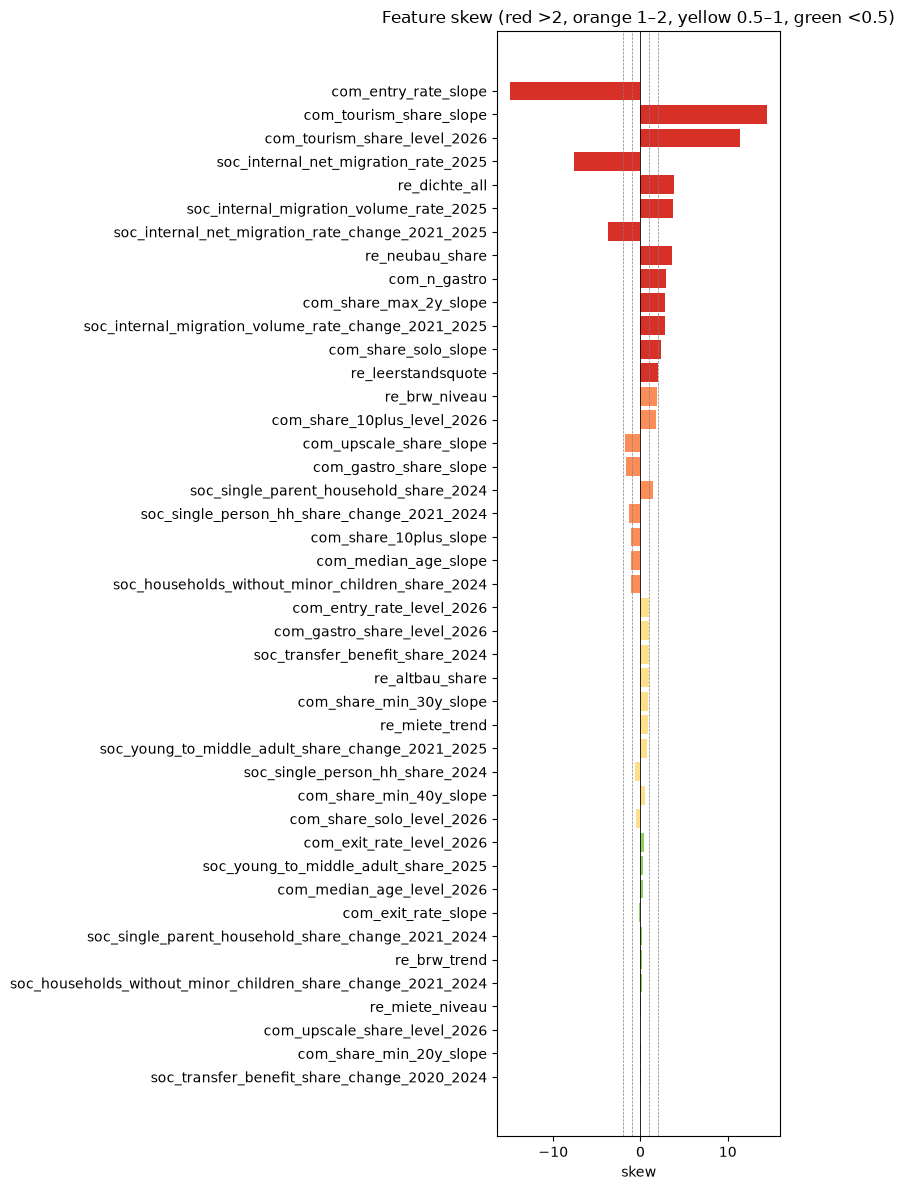

In [145]:
fig, ax = plt.subplots(figsize=(8, 12))
colors = skew.map(lambda s: "#d73027" if abs(s) > 2 else
                            "#fc8d59" if abs(s) > 1 else
                            "#fee08b" if abs(s) > 0.5 else "#91cf60")
ax.barh(skew.index[::-1], skew.values[::-1], color=colors.values[::-1])
ax.axvline(0, color="black", linewidth=0.6)
for x in (-2, -1, 1, 2):
    ax.axvline(x, color="grey", linewidth=0.5, linestyle="--")
ax.set_xlabel("skew")
ax.set_title("Feature skew (red >2, orange 1–2, yellow 0.5–1, green <0.5)")
plt.tight_layout()
plt.show()

Half of the features (22 of 44) are strongly or severely skewed, and 22 carry negative values. This means that StandardScaler (which leaves skew intact) and plain log (can't take negatives) won't work here. As an alternative, the Yeo-Johnson transformer will be used. Developed by I.K. Yeo and R.A. Johnson in 2000, this transformation is part of the power transformation family, similar to Box-Cox, but it extends its applicability to data containing non-positive values. The goal remains the same: to stabilize variance, reduce skewness, and make the data distribution more closely resemble a normal (Gaussian) distribution. The important concept is that the transformation provides a continuous function across zero and handles positive, zero, and negative values consistently to achieve symmetry. Documentation for the implementation in scikit-learn can be found here: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PowerTransformer.html.  

### Overview: Outliers

Describe

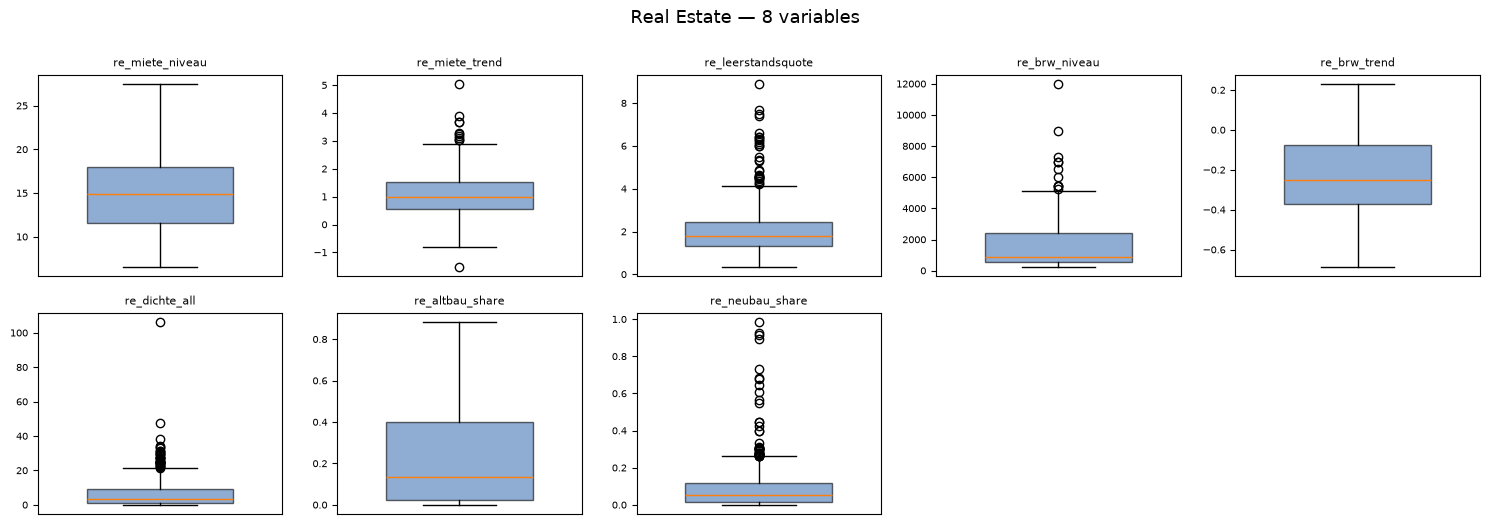

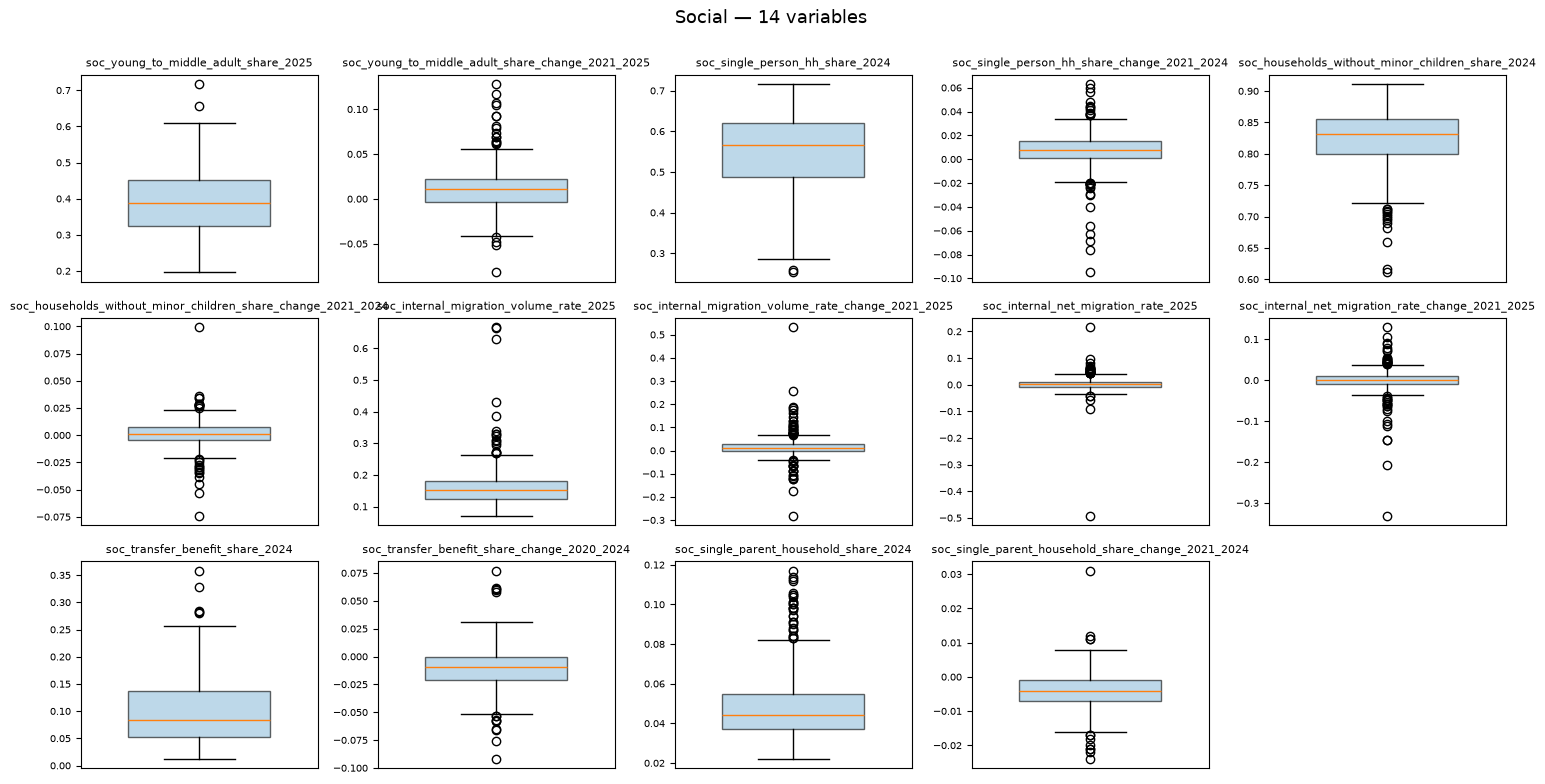

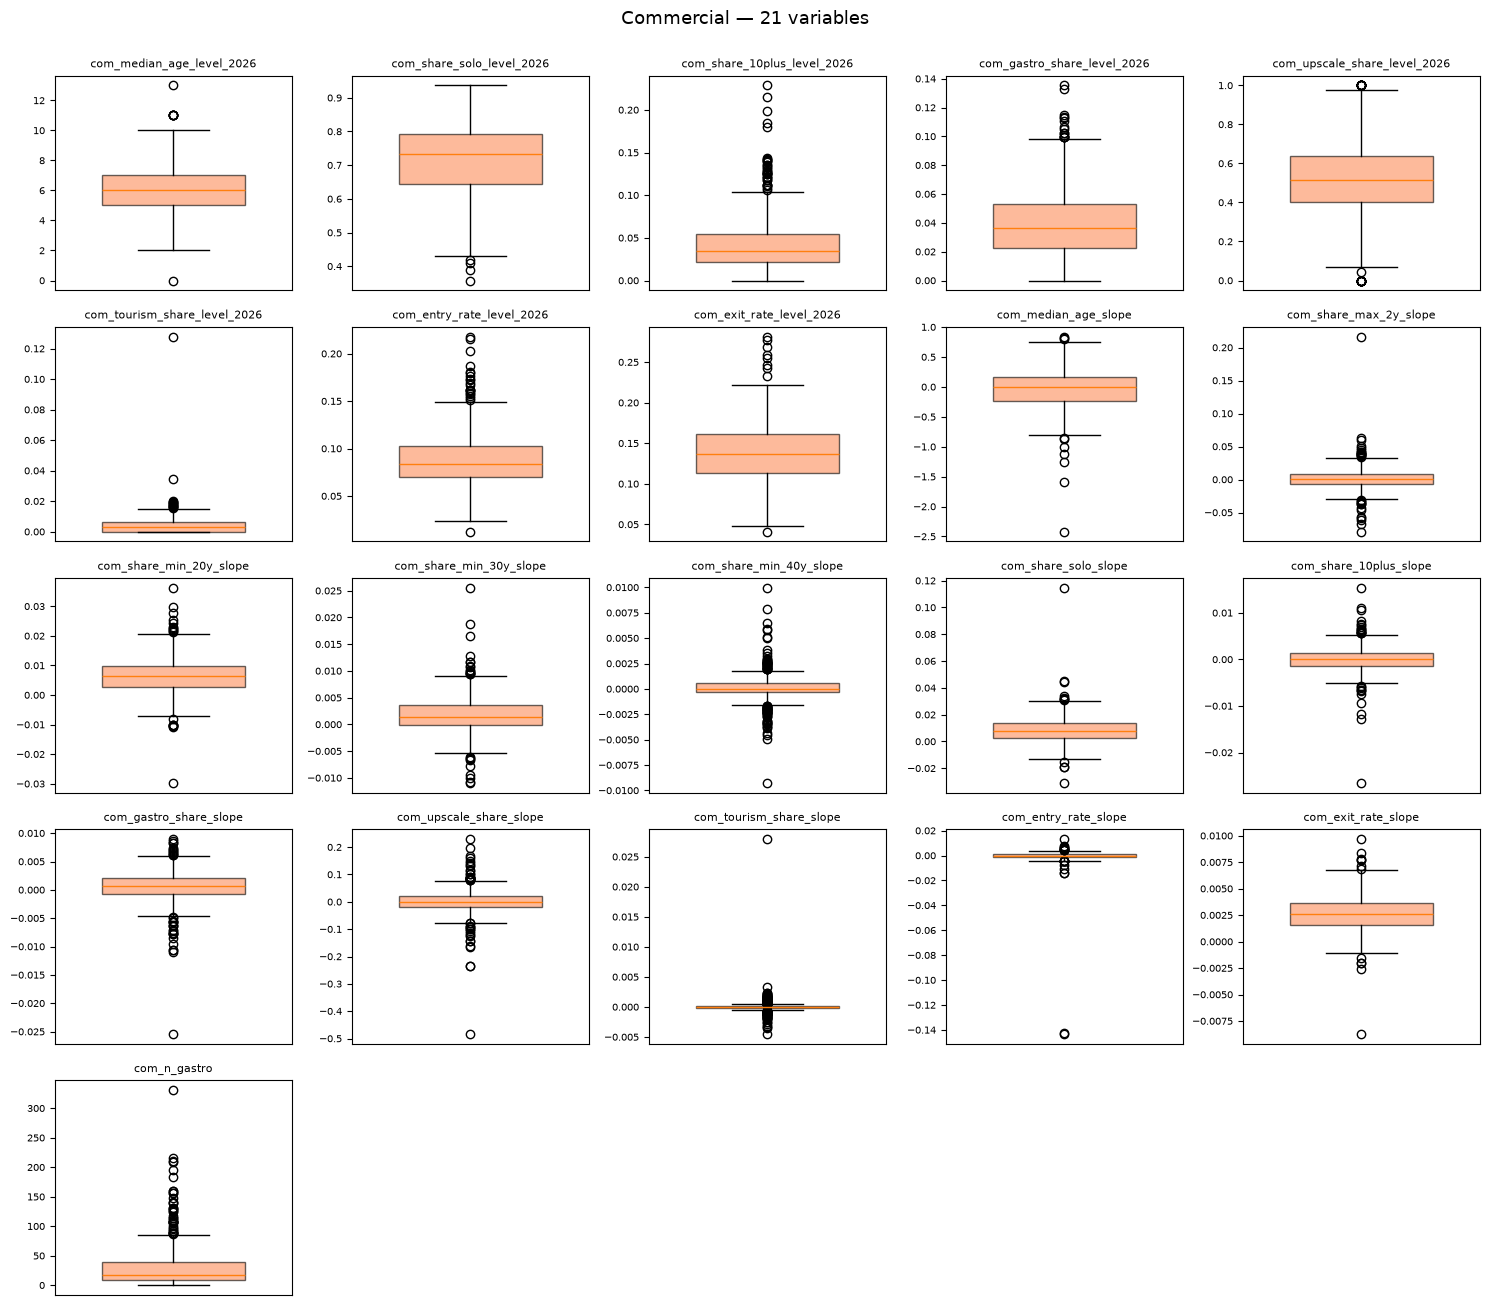

In [146]:
import math

dimensions = {
    "Real Estate": ([c for c in feat_cols if c.startswith("re_")],  "#4575b4"),
    "Social":      ([c for c in feat_cols if c.startswith("soc_")], "#91bfdb"),
    "Commercial":  ([c for c in feat_cols if c.startswith("com_")], "#fc8d59"),
}

for dim_name, (cols, col_color) in dimensions.items():
    n = len(cols)
    ncols = 5
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 2.6))
    axes = axes.flatten() if n > 1 else [axes]

    for ax, c in zip(axes, cols):
        bp = ax.boxplot(df[c].dropna(), widths=0.6, patch_artist=True)
        bp["boxes"][0].set_facecolor(col_color)
        bp["boxes"][0].set_alpha(0.6)
        ax.set_title(c, fontsize=8)
        ax.set_xticks([])
        ax.tick_params(axis="y", labelsize=7)

    for ax in axes[n:]:
        ax.set_visible(False)

    fig.suptitle(f"{dim_name} — {n} variables", fontsize=13, y=1.0)
    plt.tight_layout()

    plt.show()

The real estate variables look unremarkable. re_miete_niveau, re_brw_trend, and re_altbau_share show no outliers; re_brw_niveau, re_dichte_all, and re_neubau_share have long upper tails with several outliers, but the spread is smooth rather than spiky.

In the social dimension, the four internal migration variables stand out — soc_internal_net_migration_rate_2025, soc_internal_migration_volume_rate_2025, and their _change_2021_2025 variants. They show a tight box with extreme values flung far to one or both sides. The remaining social variables look well distributed.

In the commercial dimension, several variables look suspicious:
- com_tourism_share_slope — a near-flat box at zero with a single far outlier and a dense cloud of points.
- com_entry_rate_slope — almost all values at zero with two extreme points pulled far down.
- com_upscale_share_slope and com_gastro_share_slope — a thin box surrounded by outliers on both sides.
- com_share_min_40y_slope — a flat box with an unusually large number of outliers.
- com_tourism_share_level is strongly right-skewed (most PLRs near zero, a few high values), but the spread is smooth.

Let's look at the outliers more closely: 

In [147]:
# helper: counts a column's IQR outliers and their share in %
def iqr_stats(s):
    s = s.dropna()                              # ignore NaN
    q1, q3 = s.quantile([.25, .75])             # 1st and 3rd quartile (= box edges)
    iqr = q3 - q1                               # interquartile range (= box height)
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr         # whisker bounds (Tukey rule, factor 1.5)
    n_out = int(((s < lo) | (s > hi)).sum())    # count of values outside the whiskers
    return n_out, n_out / len(s) * 100          # absolute count + share in percent

# build the table: per variable, skew + outlier metrics
tab = pd.DataFrame([
    {"variable": c,
     "skew": round(df[c].skew(), 2),             # skew (asymmetry of the distribution)
     "n_outliers": iqr_stats(df[c])[0],          # number of IQR outliers
     "outlier_%": round(iqr_stats(df[c])[1], 1)} # share of IQR outliers
    for c in feat_cols
])

tab["abs_skew"] = tab["skew"].abs()             # magnitude of skew (direction doesn't matter)

# "suspicious" rule: strongly skewed OR many outliers
# -> catches both failure modes (long smooth tail AND detached spikes)
tab["flagged"] = (tab["abs_skew"] > 3) | (tab["outlier_%"] > 10) 

# 
# sort: flagged first, then worst skew, then most outliers
tab = tab.sort_values(
    ["flagged","outlier_%","abs_skew"],
    ascending=[False, False, False]   # flagged True on top, then descending
)

print(tab[["variable", "skew", "n_outliers", "outlier_%", "flagged"]].to_string(index=False))

                                                    variable   skew  n_outliers  outlier_%  flagged
                                     com_tourism_share_slope  14.51         131       24.9     True
                                     com_share_min_40y_slope   0.57          80       15.2     True
            soc_internal_net_migration_rate_change_2021_2025  -3.75          43        8.2     True
                                             re_neubau_share   3.56          39        7.4     True
                                               re_dichte_all   3.82          33        6.3     True
                        soc_internal_net_migration_rate_2025  -7.58          31        5.9     True
                                        com_entry_rate_slope -14.96          23        4.4     True
                     soc_internal_migration_volume_rate_2025   3.76          17        3.2     True
                                com_tourism_share_level_2026  11.43          14        2.7     True


Two of the suspicious variables from your boxplot description are not in the flagged list:

- com_upscale_share_slope — 8.0% outliers, skew −1.77
- com_gastro_share_slope — 6.5% outliers, skew −1.71

These two fall just below the thresholds (outlier share < 10%, |skew| < 3), so the rule does not catch them — but the boxplots clearly do. A reason for this might be the fact that these variables are within-gastro share-slopes, whose values become unstable when a PLR has only a few gastro businesses. The instability is structural (a small denominator) rather than a matter of raw outlier count, so it does not always surface as a high outlier percentage.

The next step is therefore to examine the outliers per variable individually — identifying which PLRs drive the tails and checking each against the relevant business base (n_gastro for gastro/upscale shares, n_tourism for tourism shares) — to distinguish genuine signal (real structure on a solid base) from small-base artifacts. Both flagged and not-flagged suspicious variables are included in this check, so that the two variables the rule missed are not dropped from the investigation.

#### Outlier Check: Commercial Dimension

In [148]:
#load tourism share out of the yearly panel
yearly = pd.read_csv("../../data/commercial/IHK_Berlin_Gewerbedaten/analysis_ready_data/yearly_panel_merged.csv",
    dtype={"planungsraum_id": str})

# n_tourism für ein bestimmtes Jahr (z.B. 2025) herausziehen
n_2026 = yearly.loc[yearly["year"] == 2026, ["planungsraum_id", "n_total","n_tourism"]]
print(n_2026.head())

     planungsraum_id      n_total  n_tourism
1626        01100101   738.333333  12.666667
1627        01100102  1555.166667  11.166667
1628        01100103  1397.833333  16.000000
1629        01100104   841.833333   4.000000
1630        01100205  1723.333333  24.000000


In [149]:
# n_tour und n_gesamt sauber anfügen
df = df.merge(
    n_2026.rename(columns={"planungsraum_id": "plr_id"})
             .assign(plr_id=lambda d: d["plr_id"].astype(str).str.zfill(8))
             [["plr_id", "n_tourism", "n_total"]],          # n_total ergänzt
    left_on=df["plr_id"].astype(str).str.zfill(8),
    right_on="plr_id", how="left", suffixes=("", "_key")
)
print("gematcht:", df[["n_tourism", "n_total"]].notna().all(axis=1).sum(), "von", len(df))

gematcht: 527 von 527


In [150]:
print("PLRs mit ~0 Tourismus (<0.5):", (df["n_tourism"] < 0.5).sum(), "von", len(df))
print("PLRs mit n_tourism < 3:", (df["n_tourism"] < 3).sum())

PLRs mit ~0 Tourismus (<0.5): 155 von 527
PLRs mit n_tourism < 3: 337


A large majority of PLRs have less than 3 tourism establishments. This means that the share slope will be very unstable and noisy. 

In [151]:
suspicious = ["com_tourism_share_slope", "com_share_min_40y_slope",
              "com_entry_rate_slope", "com_tourism_share_level_2026",
              "com_upscale_share_slope", "com_gastro_share_slope"]

# map each variable to the base that actually applies to it
base_for = {
    "com_entry_rate_slope":          "n_total",       # alle Betriebe
    "com_gastro_share_slope":        "n_total",       # Gastro / alle Betriebe
    "com_share_min_40y_slope":       "n_total",
    "com_upscale_share_slope":       "com_n_gastro",  # Upscale / Gastro
    "com_tourism_share_slope":       "n_tourism",
    "com_tourism_share_level_2026":  "n_tourism",
}

def iqr_out(s):
    q1, q3 = s.quantile([.25, .75]); iqr = q3 - q1
    return s[(s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)]

for c in suspicious:
    base = base_for[c]
    have_base = base in df.columns          # n_tour only present if merged in
    ext = iqr_out(df[c]).abs().sort_values(ascending=False).head(8).index
    print(f"\n{c}  (base = {base}{'' if have_base else '  — NOT in df, merge first'})")
    for i in ext:
        b = f"{df[base][i]:.0f}" if have_base else "?"
        print(f"   {df[c][i]:+.4g}   {df['plr_name'][i]:28s} {base}={b}")


com_tourism_share_slope  (base = n_tourism)
   +0.02796   Perelsplatz                  n_tourism=156
   -0.004516   Heiligensee Nord             n_tourism=1
   -0.003456   Gleisdreieck                 n_tourism=5
   +0.003393   Maulbeerallee                n_tourism=7
   -0.003284   Vogelviertel Süd             n_tourism=4
   -0.00316   Flatowallee                  n_tourism=2
   -0.002873   Londoner Straße              n_tourism=0
   -0.002561   Alt-Gatow                    n_tourism=2

com_share_min_40y_slope  (base = n_total)
   +0.009958   Am Forstacker                n_total=130
   -0.009256   Barbarossaplatz              n_total=985
   +0.00785   Siedlung Kämmereiheide       n_total=71
   +0.006535   Messelpark                   n_total=253
   +0.005936   Kafkastraße                  n_total=273
   +0.005752   Binger Straße                n_total=241
   +0.005116   Thomasiusstraße              n_total=762
   +0.005058   Wriezener Bahnhof            n_total=600

com_entry_rate_sl

Commercial dimension — base-size check

Each suspicious variable was checked against its own denominator. Share-slopes only collapse when the denominator is a thin sub-category. Redundancy was checked for the remaining candidates (min-age slope family, gastro slope vs. level): all correlations ≤ 0.39, so none are redundant.

**Drop:**
- com_upscale_share_slope — base n_gastro; extremes on 1–4 businesses. Noise.
- com_tourism_share_slope — base n_tourism; extremes on 0–7, and 64% of PLRs have < 3 tourism businesses.

**Keep:**
- com_tourism_share_level — real hubs on solid bases (Perelsplatz 156); a 0 is a genuine value.
- com_gastro_share_slope — base n_total (large bases); not redundant with its level (r = 0.37). No reason to drop.
- com_entry_rate_slope — base n_total; all extremes on large bases (Karow 258/404, Ringstraße 2537), so they are real movements, not artifacts.
- com_share_min_40y_slope — base n_total (large bases); not redundant with its 20y/30y siblings (r ≤ 0.39). A flat box with a high outlier share makes it weakly informative, but its outliers are real, so there is no small-base or redundancy reason to drop.

**Note on outliers:** the remaining extreme values (e.g. Karow on com_entry_rate_slope) sit on large bases and are real, not artifacts. Yeo-Johnson is expected to compress them. These variables are kept as-is; capping is a last resort only if a point remains disproportionate after transformation (e.g. if a single extreme still distorts the fitted λ) — not an automatic response to a spiky boxplot.

Rule: divided by a thin sub-category → collapses → drop; divided by all businesses → broad base → keep. Base size decides keep-vs-drop; the transform handles magnitude; capping only if a real-but-extreme point still distorts after transformation.

In [152]:
X_imp = X_imp.drop(columns=["com_upscale_share_slope", "com_tourism_share_slope"])

In [153]:
X_imp.head(3)

,re_miete_niveau,re_miete_trend,re_leerstandsquote,re_brw_niveau,re_brw_trend,re_dichte_all,soc_young_to_middle_adult_share_2025,soc_young_to_middle_adult_share_change_2021_2025,soc_single_person_hh_share_2024,soc_single_person_hh_share_change_2021_2024,...,com_share_min_30y_slope,com_share_min_40y_slope,com_share_solo_slope,com_share_10plus_slope,com_gastro_share_slope,com_entry_rate_slope,com_exit_rate_slope,com_n_gastro,re_altbau_share,re_neubau_share
0,22.7,2.142,3.050847,3890.584913,-0.326098,10.653753,0.460,0.000,0.624,-0.004,...,0.001367,-0.000276,0.024083,0.002754,0.003153,-0.002800,0.001395,13.000000,0.118160,0.102663
1,20.3,1.059,4.557180,3440.019389,-0.426678,24.075666,0.479,0.003,0.535,-0.010,...,0.003015,0.001063,0.028592,0.002506,0.004856,-0.000930,-0.000664,129.333333,0.228719,0.297506
2,23.0,1.356,1.863997,3541.826020,-0.440097,16.223680,0.455,0.022,0.603,0.006,...,0.001498,0.001101,0.032530,-0.001222,0.000177,-0.001019,0.000103,43.833333,0.323783,0.130135


#### Outlier Check: Social Dimension

In [154]:
# the four social migration variables
migr = [c for c in df.columns if c.startswith("soc_") and "migration" in c]

# return a column's IQR outliers (Tukey rule)
def iqr_out(s):
    q1, q3 = s.quantile([.25, .75])
    iqr = q3 - q1
    return s[(s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)]

# per variable: the most extreme outlier PLRs by name
for c in migr:
    ext = iqr_out(df[c])
    ext_idx = ext.abs().sort_values(ascending=False).head(8).index
    print(f"\n{c}  — {len(ext)} outliers")
    for i in ext_idx:
        print(f"   {df[c][i]:+.4g}   {df['plr_name'][i]} ({df['bez'][i]})")


soc_internal_migration_volume_rate_2025  — 17 outliers
   +0.666   Volkspark Prenzlauer Berg (03 - Pankow)
   +0.664   Wittenau Süd (12 - Reinickendorf)
   +0.63   Paradestraße (07 - Tempelhof-Schöneberg)
   +0.429   Bornitzstraße (11 - Lichtenberg)
   +0.387   Freiheit (05 - Spandau)
   +0.338   Herzbergstraße (11 - Lichtenberg)
   +0.33   Stralauer Kiez (02 - Friedrichshain-Kreuzberg)
   +0.329   Dorf Falkenberg (11 - Lichtenberg)

soc_internal_migration_volume_rate_change_2021_2025  — 46 outliers
   +0.531   Paradestraße (07 - Tempelhof-Schöneberg)
   -0.281   Haveleck (05 - Spandau)
   +0.257   Volkspark Prenzlauer Berg (03 - Pankow)
   +0.188   Freiheit (05 - Spandau)
   +0.182   Angerburger Allee (04 - Charlottenburg-Wilmersdorf)
   +0.176   Marzahner Chaussee (10 - Marzahn-Hellersdorf)
   -0.173   Herzbergstraße (11 - Lichtenberg)
   +0.162   Askanischer Platz (02 - Friedrichshain-Kreuzberg)

soc_internal_net_migration_rate_2025  — 31 outliers
   -0.492   Wittenau Süd (12 - Rei

In [155]:
# count how many of the four migration variables each PLR is an outlier on
flags = pd.DataFrame(index=df.index)
for c in migr:
    flags[c] = df.index.isin(iqr_out(df[c]).index)

df_rep = df.assign(n_migr_outlier=flags.sum(axis=1))
repeat = (df_rep.loc[df_rep["n_migr_outlier"] > 0,
                     ["plr_id", "plr_name", "bez", "n_migr_outlier"]]
                .sort_values("n_migr_outlier", ascending=False))
print(repeat.to_string(index=False))

  plr_id                  plr_name                             bez  n_migr_outlier
10100311        Marzahner Chaussee        10 - Marzahn-Hellersdorf               4
12500930              Wittenau Süd              12 - Reinickendorf               4
05100317                  Freiheit                    05 - Spandau               4
02100101         Askanischer Platz   02 - Friedrichshain-Kreuzberg               4
09100409 Landschaftspark Adlershof           09 - Treptow-Köpenick               4
03300516               Heinersdorf                     03 - Pankow               3
04200204         Angerburger Allee 04 - Charlottenburg-Wilmersdorf               3
09401329   Kietzer Feld/Nachtheide           09 - Treptow-Köpenick               3
05100103             Mertensstraße                    05 - Spandau               3
07400721              Paradestraße       07 - Tempelhof-Schöneberg               3
11100102           Dorf Falkenberg                11 - Lichtenberg               3
0320

## Yeo-Johnson transformer

This transformer is sensitive to outliers 